# <center>**EDA & Feature Engineering**</center>

In this notebook, we will load our high-frequency Limit Order Book (LOB) data from the Parquet file and calculate meaningful micro-structure features such as **Mid-Price**, **Bid-Ask Spread**, and **Volume Imbalance**.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set display options for Pandas
pd.set_option('display.max_columns', None)

In [13]:
# load parquet data
df = pd.read_parquet('lob_data.parquet')
df['timestamp'] = pd.to_datetime(df['timestamp'], format='ISO8601')
df.set_index('timestamp', inplace=True)
df.head()

,bid1_price,bid1_qty,ask1_price,ask1_qty,bid2_price,bid2_qty,ask2_price,ask2_qty,bid3_price,bid3_qty,ask3_price,ask3_qty,bid4_price,bid4_qty,ask4_price,ask4_qty,bid5_price,bid5_qty,ask5_price,ask5_qty,bid6_price,bid6_qty,ask6_price,ask6_qty,bid7_price,bid7_qty,ask7_price,ask7_qty,bid8_price,bid8_qty,ask8_price,ask8_qty,bid9_price,bid9_qty,ask9_price,ask9_qty,bid10_price,bid10_qty,ask10_price,ask10_qty,bid11_price,bid11_qty,ask11_price,ask11_qty,bid12_price,bid12_qty,ask12_price,ask12_qty,bid13_price,bid13_qty,ask13_price,ask13_qty,bid14_price,bid14_qty,ask14_price,ask14_qty,bid15_price,bid15_qty,ask15_price,ask15_qty,bid16_price,bid16_qty,ask16_price,ask16_qty,bid17_price,bid17_qty,ask17_price,ask17_qty,bid18_price,bid18_qty,ask18_price,ask18_qty,bid19_price,bid19_qty,ask19_price,ask19_qty,bid20_price,bid20_qty,ask20_price,ask20_qty
timestamp,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-07-05 02:20:02.574406,63317.99,5.30667,63318.0,0.14434,63317.98,0.00016,63318.01,0.00115,63317.97,0.00016,63318.02,0.00059,63317.87,0.00018,63318.13,0.00008,63317.86,0.05311,63318.37,0.00008,63317.7,0.00651,63318.8,0.00008,63317.69,0.07706,63319.09,0.00018,63317.68,0.09361,63319.1,0.09306,63317.3,0.00008,63319.61,0.00008,63316.98,0.004,63319.99,0.00214,63316.85,0.00071,63320.0,0.12498,63316.8,0.00862,63320.01,0.00109,63316.79,0.00018,63320.28,0.00018,63316.78,0.05234,63320.67,0.00232,63316.6,0.00009,63320.78,0.00016,63316.59,0.03951,63320.83,0.00071,63316.46,0.00009,63321.24,0.00016,63316.4,0.03,63321.25,0.00028,63316.01,0.00008,63321.32,0.00008,63316.0,0.00015,63321.42,0.00027
2026-07-05 02:20:02.598736,63317.99,5.30667,63318.0,0.14434,63317.98,0.00016,63318.01,0.00115,63317.97,0.00016,63318.02,0.00059,63317.87,0.00018,63318.13,0.00008,63317.86,0.05311,63318.37,0.00008,63317.7,0.00651,63318.8,0.00008,63317.69,0.07706,63319.09,0.00018,63317.68,0.09361,63319.1,0.09306,63317.3,0.00008,63319.61,0.00008,63316.98,0.004,63319.99,0.00214,63316.85,0.00071,63320.0,0.12498,63316.8,0.00862,63320.01,0.00109,63316.79,0.00018,63320.28,0.00018,63316.78,0.05234,63320.67,0.00232,63316.6,0.00009,63320.78,0.00016,63316.59,0.03951,63320.83,0.00071,63316.46,0.00009,63321.24,0.00016,63316.4,0.03,63321.25,0.00028,63316.01,0.00008,63321.32,0.00008,63316.0,0.00015,63321.42,0.00027
2026-07-05 02:20:02.701632,63317.99,5.30667,63318.0,0.14434,63317.98,0.00016,63318.01,0.00115,63317.97,0.00016,63318.02,0.00059,63317.87,0.00018,63318.13,0.00008,63317.86,0.05311,63318.37,0.00008,63317.7,0.00651,63318.8,0.00008,63317.69,0.07706,63319.09,0.00018,63317.68,0.09361,63319.1,0.09306,63317.3,0.00008,63319.61,0.00008,63316.98,0.004,63319.99,0.00214,63316.85,0.00071,63320.0,0.12498,63316.8,0.00862,63320.01,0.00109,63316.79,0.00018,63320.28,0.00018,63316.78,0.05234,63320.67,0.00232,63316.6,0.00009,63320.78,0.00016,63316.59,0.03951,63320.83,0.00071,63316.46,0.00009,63321.24,0.00016,63316.4,0.03,63321.25,0.00028,63316.01,0.00008,63321.32,0.00008,63316.0,0.00015,63321.42,0.00027
2026-07-05 02:20:02.810271,63317.99,5.30667,63318.0,0.14434,63317.98,0.00016,63318.01,0.00115,63317.97,0.00016,63318.02,0.00059,63317.87,0.00018,63318.13,0.00008,63317.86,0.05311,63318.37,0.00008,63317.7,0.00651,63318.8,0.00008,63317.69,0.07706,63319.09,0.00018,63317.68,0.09361,63319.1,0.09306,63317.3,0.00008,63319.61,0.00008,63316.98,0.004,63319.99,0.00214,63316.85,0.00071,63320.0,0.12498,63316.8,0.00862,63320.01,0.00109,63316.79,0.00018,63320.28,0.00018,63316.78,0.05234,63320.67,0.00232,63316.6,0.00009,63320.78,0.00016,63316.59,0.03951,63320.83,0.00071,63316.46,0.00009,63321.24,0.00016,63316.4,0.03,63321.25,0.00028,63316.01,0.00008,63321.32,0.00008,63316.0,0.00015,63321.42,0.00027
2026-07-05 02:20:02.892243,63317.99,5.30667,63318.0,0.14784,63317.98,0.00016,63318.01,0.00115,63317.97,0.00016,63318.02,0.00059,63317.87,0.00018,63318.13,0.00008,63317.86,0.05311,63318.37,0.00008,63317.7,0.00651,63318.8,0.00008,63317.69,0.07706,63319.09,0.00018,63317.68,0.09361,63319.1,0.09306,63

### Basic LOB Metrics
We need to compute the essential features of the limit order book at the top level (level 1).

- **Mid-Price**: The average of the best bid and best ask.
- **Spread**: The difference between the best ask and best bid.
- **Volume Imbalance**: Normalised difference between bid volume and ask volume.

In [14]:
# Mid-Price
df['mid_price'] = (df['ask1_price'] + df['bid1_price']) / 2

# Spread
df['spread'] = df['ask1_price'] - df['bid1_price']

# Volume Imbalance at Level 1
# Value between -1 (extreme sell pressure) and 1 (extreme buy pressure)
df['vol_imbalance_1'] = (df['bid1_qty'] - df['ask1_qty']) / (df['bid1_qty'] + df['ask1_qty'])

df[['mid_price', 'spread', 'vol_imbalance_1']].head()

,mid_price,spread,vol_imbalance_1
timestamp,,,
2026-07-05 02:20:02.574406,63317.995,0.01,0.947041
2026-07-05 02:20:02.598736,63317.995,0.01,0.947041
2026-07-05 02:20:02.701632,63317.995,0.01,0.947041
2026-07-05 02:20:02.810271,63317.995,0.01,0.947041
2026-07-05 02:20:02.892243,63317.995,0.01,0.945792


### Visualisation
Let's plot the mid-price alongside the volume imbalance to see if we can spot any visual correlation before we train a model.

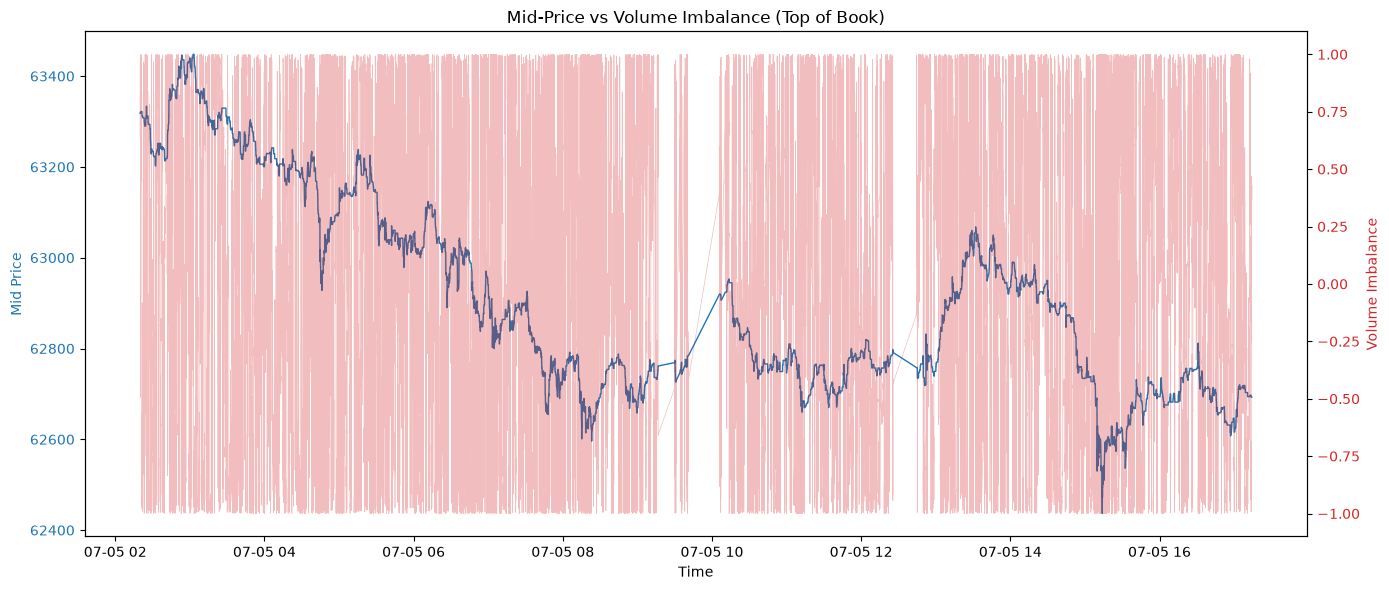

In [15]:
fig, ax1 = plt.subplots(figsize=(14, 6))

color = 'tab:blue'
ax1.set_xlabel('Time')
ax1.set_ylabel('Mid Price', color=color)
ax1.plot(df.index, df['mid_price'], color=color, linewidth=1)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Volume Imbalance', color=color)
ax2.plot(df.index, df['vol_imbalance_1'], color=color, alpha=0.3, linewidth=0.5)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Mid-Price vs Volume Imbalance (Top of Book)')
fig.tight_layout()
plt.show()

### Multi-Level Volume Imbalance
Level 1 only shows the very top of the book. Aggregating imbalance across multiple levels gives a more robust view of supply/demand pressure.

In [16]:
# Aggregate Volume Imbalance across the top 5 levels
total_bid_qty = sum(df[f'bid{i}_qty'] for i in range(1, 6))
total_ask_qty = sum(df[f'ask{i}_qty'] for i in range(1, 6))
df['vol_imbalance_5'] = (total_bid_qty - total_ask_qty) / (total_bid_qty + total_ask_qty)

# Weighted Mid-Price: weighted by volume across the top 5 levels
bid_vwap = sum(df[f'bid{i}_price'] * df[f'bid{i}_qty'] for i in range(1, 6)) / total_bid_qty
ask_vwap = sum(df[f'ask{i}_price'] * df[f'ask{i}_qty'] for i in range(1, 6)) / total_ask_qty
df['weighted_mid'] = (bid_vwap + ask_vwap) / 2

df[['mid_price', 'weighted_mid', 'vol_imbalance_5']].head()

,mid_price,weighted_mid,vol_imbalance_5
timestamp,,,
2026-07-05 02:20:02.574406,63317.995,63317.994570,0.946885
2026-07-05 02:20:02.598736,63317.995,63317.994570,0.946885
2026-07-05 02:20:02.701632,63317.995,63317.994570,0.946885
2026-07-05 02:20:02.810271,63317.995,63317.994570,0.946885
2026-07-05 02:20:02.892243,63317.995,63317.994565,0.945648


### Define the Target Variable
We need to predict the direction of the mid-price movement `k` steps in the future. We use a smoothed future price (mean over next 10 ticks) to reduce noise and avoid predicting micro-fluctuations.

In [ ]:
HORIZON = 10  # Number of ticks to look ahead
THRESHOLD = 0.0001  # Minimum price change to be called UP/DOWN (to avoid labelling noise)

# Smooth future price: mean mid-price over the next HORIZON ticks
df['future_mid'] = df['mid_price'].shift(-HORIZON).rolling(HORIZON).mean()

# Relative change from current mid-price
df['price_change'] = (df['future_mid'] - df['mid_price']) / df['mid_price']

# Label: 1 = UP, -1 = DOWN, 0 = STATIONARY
df['label'] = 0
df.loc[df['price_change'] > THRESHOLD, 'label'] = 1
df.loc[df['price_change'] < -THRESHOLD, 'label'] = -1

# Drop rows at the end that have no future label
df.dropna(subset=['future_mid'], inplace=True)

print('Label Distribution:')
print(df['label'].value_counts())

Label Distribution:
label
 0    491839
-1      2159
 1      1811
Name: count, dtype: int64


### Data Normalization (Rolling Z-Score)
LOB data is highly non-stationary — BTC's price today is very different from 6 months ago. We must normalize features using a **rolling Z-score** rather than a global mean/std.
This ensures the model only sees *relative* changes, not absolute price levels.

In [18]:
WINDOW = 100  # Number of ticks to use for rolling normalization

# Select the feature columns to normalize (exclude the label and future prices)
feature_cols = [
    'mid_price', 'spread', 'vol_imbalance_1', 'vol_imbalance_5', 'weighted_mid'
]

# Apply rolling Z-score normalization
df_norm = df[feature_cols].copy()
rolling_mean = df_norm.rolling(window=WINDOW).mean()
rolling_std  = df_norm.rolling(window=WINDOW).std()
df_norm = (df_norm - rolling_mean) / (rolling_std + 1e-9)  # 1e-9 avoids division by zero

# Add the label back
df_norm['label'] = df['label']

# Drop the initial rows where we don't have enough history for the rolling window
df_norm.dropna(inplace=True)

print(f'Normalized dataset shape: {df_norm.shape}')
df_norm.head()

Normalized dataset shape: (495710, 6)


,mid_price,spread,vol_imbalance_1,vol_imbalance_5,weighted_mid,label
timestamp,,,,,,
2026-07-05 02:20:13.300255,0.994987,0.0,0.897599,0.903098,1.002736,0
2026-07-05 02:20:13.390834,0.975283,0.0,0.911085,0.916680,0.982880,0
2026-07-05 02:20:13.493951,0.955953,0.0,0.934120,0.939803,0.963408,0
2026-07-05 02:20:13.593091,0.936976,0.0,0.970619,0.975924,0.944274,0
2026-07-05 02:20:13.689849,0.918332,0.0,1.032792,1.037827,0.925503,0


### Train - Validation - Test Split (by Time)
> **Critical:** We MUST split by time, never randomly. A random split would allow future data to leak into the training set (look-ahead bias), producing fake results.

We use a standard 70% / 15% / 15% split.

In [19]:
n = len(df_norm)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_df = df_norm.iloc[:train_end]
val_df   = df_norm.iloc[train_end:val_end]
test_df  = df_norm.iloc[val_end:]

print(f'Total rows   : {n}')
print(f'Training set : {len(train_df)} rows ({train_df.index[0]} → {train_df.index[-1]})')
print(f'Validation   : {len(val_df)}   rows ({val_df.index[0]} → {val_df.index[-1]})')
print(f'Test set     : {len(test_df)}  rows ({test_df.index[0]} → {test_df.index[-1]})')

# Save the splits as separate Parquet files for use in the modelling notebook
train_df.to_parquet('train.parquet')
val_df.to_parquet('val.parquet')
test_df.to_parquet('test.parquet')
print('\nSplit files saved: train.parquet, val.parquet, test.parquet')

Total rows   : 495710
Training set : 346997 rows (2026-07-05 02:20:13.300255 → 2026-07-05 13:02:50.160948)
Validation   : 74356   rows (2026-07-05 13:02:50.161015 → 2026-07-05 15:10:16.329394)
Test set     : 74357  rows (2026-07-05 15:10:16.429022 → 2026-07-05 17:14:12.212494)

Split files saved: train.parquet, val.parquet, test.parquet
